# 第2章 確率 (Probabilities)
## 2.3 ガウス分布 (The Gaussian Distribution)

本ノートブックは、教科書『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』(Bishop & Bishop, 2024) の **第2章 2.3節「ガウス分布 (The Gaussian Distribution)」** を完全に網羅し、厳密な数学的導出、対話的なPython実装、教科書図版（Figure 2.8 〜 2.11）の完全再現、および深層学習との本質的関連性を解説するものです。

---

### 目次 (Table of Contents)
1. [2.3 ガウス分布の導入と基本特性](#sec2_3_intro)
   - ガウス分布の定義式 (式 2.49) と精度パラメータ (式 2.50)
   - ガウス積分の完全導出と正規化条件 (式 2.51)
   - Figure 2.8: ガウス分布の概形・平均 $\mu$・標準偏差 $2\sigma$ 幅
2. [2.3.1 平均と分散 (Mean and Variance)](#sec2_3_1)
   - 1次モーメント（期待値・平均）のステップバイステップ導出 (式 2.52)
   - 2次モーメントの完全導出 (式 2.53)
   - 分散と最頻値 (モード) (式 2.54)
3. [2.3.2 尤度関数 (Likelihood Function)](#sec2_3_2)
   - 独立同分布 (i.i.d.) 仮定と尤度関数の定義 (式 2.55)
   - Figure 2.9: ガウス尤度関数の模式図とデータ点の寄与
   - 対数尤度関数の導出 (式 2.56)
   - 最尤推定量 $\mu_{\mathrm{ML}}$ および $\sigma^2_{\mathrm{ML}}$ の微分導出 (式 2.57, 2.58)
   - パラメータ推定の分離性 (Decoupling)
4. [2.3.3 最尤推定のバイアス (Bias of Maximum Likelihood)](#sec2_3_3)
   - 推定量のバイアス (偏り) の定義
   - 標本平均 $\mu_{\mathrm{ML}}$ の不偏性の証明 (式 2.59)
   - 標本分散 $\sigma^2_{\mathrm{ML}}$ の過小評価・バイアスの完全証明 (式 2.60)
   - 真の平均に対する分散推定量との対比 (式 2.61, 2.62)
   - ベッセル補正による不偏分散推定量 $\tilde{\sigma}^2$ (式 2.63)
   - Figure 2.10: 最尤推定による分散バイアスの直感的視覚化 ($N=2$)
   - モンテカルロシミュレーションによるバイアス検証と漸近的一致性
5. [2.3.4 線形回帰 (Linear Regression)](#sec2_3_4)
   - 確率的線形回帰と条件付きガウス分布 (式 2.64)
   - Figure 2.11: 条件付きガウス分布 $p(t|x, \mathbf{w}, \sigma^2)$ の立体・断面模式図
   - 目的変数ベクトルの尤度と対数尤度 (式 2.65, 2.66)
   - 最尤推定と二乗和誤差最小化の厳密な等価性 (式 2.67)
   - ノイズ分散の最尤推定量 (式 2.68)
   - 予測分布 (Predictive Distribution) (式 2.69) と信頼区間
6. [深層学習との架け橋 (Deep Learning Connections)](#sec2_3_dl)
   - なぜ深層学習でMSE損失が広く使われるのか（ガウス尤度最大化としての解釈）
   - 変分オートエンコーダ (VAE) の潜在空間におけるガウス分布
   - 拡散モデル (Diffusion Models) におけるガウス雑音付加・除去過程


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, special

# プロジェクトルートパスの設定
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from common.plot_utils import setup_style, save_plot
from common.probability import (
    Gaussian1D,
    gaussian_maximum_likelihood,
    simulate_gaussian_mle_bias,
    GaussianLinearRegression
)

# プロットスタイルの初期化
setup_style()
print("Libraries and common modules loaded successfully.")


Libraries and common modules loaded successfully.


<a id="sec2_3_intro"></a>
---
## 2.3 ガウス分布の導入と基本特性 (Introduction to Gaussian Distribution)

連続確率変数を扱う確率論および機械学習において、最も広く使われ、最も中心的な役割を担う確率分布が **ガウス分布 (Gaussian Distribution)**、別名 **正規分布 (Normal Distribution)** です。

### 1変量ガウス分布の定義式
単一の連続変数 $x \in (-\infty, \infty)$ に対するガウス分布は、平均パラメータ $\mu$ および分散パラメータ $\sigma^2$（ただし標準偏差 $\sigma > 0$）によって以下のように定義されます：

$$
\mathcal{N}(x | \mu, \sigma^2) = \frac{1}{(2\pi \sigma^2)^{1/2}} \exp \left\{ -\frac{1}{2\sigma^2}(x - \mu)^2 \right\} \tag{2.49}
$$

また、分散の逆数として **精度 (Precision)** パラメータ $\beta$ を定義することが頻繁に行われます：

$$
\beta \equiv \frac{1}{\sigma^2} \tag{2.50}
$$

精度 $\beta$ を用いると、ガウス分布は次のように簡潔に表されます：

$$
\mathcal{N}(x | \mu, \beta^{-1}) = \left( \frac{\beta}{2\pi} \right)^{1/2} \exp \left\{ -\frac{\beta}{2}(x - \mu)^2 \right\}
$$

分散 $\sigma^2$ が不確実性の広がりを表すのに対し、精度 $\beta$ は「どれだけ鋭く平均値の周囲に集中しているか（確信度）」を直感的に表します。

---

### 正規化条件の厳密な導出 (式 2.51)
確率密度関数として妥当であるためには、全空間での積分値が $1$ にならなければなりません：

$$
\int_{-\infty}^{\infty} \mathcal{N}(x | \mu, \sigma^2) \, \mathrm{d}x = 1 \tag{2.51}
$$

#### 【ステップバイステップ導出】
1. **変数変換 (置換積分)**:
   $u = \frac{x - \mu}{\sqrt{2}\sigma}$ と置換すると、$\mathrm{d}x = \sqrt{2}\sigma \, \mathrm{d}u$ となります。積分範囲は $(-\infty, \infty)$ のまま不変です：
   $$
   I = \int_{-\infty}^{\infty} \frac{1}{\sqrt{2\pi \sigma^2}} \exp \left( -u^2 \right) \sqrt{2}\sigma \, \mathrm{d}u = \frac{1}{\sqrt{\pi}} \int_{-\infty}^{\infty} \exp(-u^2) \, \mathrm{d}u
   $$

2. **ガウス積分の計算 (2重積分と極座標変換)**:
   $J = \int_{-\infty}^{\infty} \exp(-u^2) \, \mathrm{d}u$ とおくと、その2乗は独立な2つの積分の直積として書けます：
   $$
   J^2 = \left( \int_{-\infty}^{\infty} e^{-u^2} \, \mathrm{d}u \right) \left( \int_{-\infty}^{\infty} e^{-v^2} \, \mathrm{d}v \right) = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} e^{-(u^2 + v^2)} \, \mathrm{d}u \, \mathrm{d}v
   $$
   ここで極座標 $u = r \cos\theta, v = r \sin\theta$ （ヤコビアン $\mathrm{d}u\mathrm{d}v = r \mathrm{d}r\mathrm{d}\theta$）に変換します：
   $$
   J^2 = \int_{0}^{2\pi} \mathrm{d}\theta \int_{0}^{\infty} e^{-r^2} r \, \mathrm{d}r = 2\pi \left[ -\frac{1}{2} e^{-r^2} \right]_0^\infty = 2\pi \cdot \left( 0 - \left(-\frac{1}{2}\right) \right) = \pi
   $$
   したがって、$J = \sqrt{\pi}$ が得られます。

3. **正規化係数の相殺**:
   $$
   I = \frac{1}{\sqrt{\pi}} \cdot \sqrt{\pi} = 1
   $$
   これにより、正規化定数 $\frac{1}{(2\pi \sigma^2)^{1/2}}$ が正しく確率密度全体の積分を $1$ に保っていることが厳密に示されました。


In [2]:
# ガウス密度の正規化数値積分検証
test_cases = [(0.0, 1.0), (2.0, 0.5), (-1.5, 3.0)]

print("=== ガウス分布の正規化検証 (式 2.51) ===")
for mu_val, s2_val in test_cases:
    g = Gaussian1D(mu=mu_val, sigma2=s2_val)
    # 数値積分
    integral_val, abserr = integrate.quad(g.pdf, -np.inf, np.inf)
    print(f"mu = {mu_val:5.1f}, sigma^2 = {s2_val:4.1f} | 積分値 = {integral_val:.10f} (誤差: {abserr:.2e})")


=== ガウス分布の正規化検証 (式 2.51) ===
mu =   0.0, sigma^2 =  1.0 | 積分値 = 1.0000000000 (誤差: 1.02e-08)
mu =   2.0, sigma^2 =  0.5 | 積分値 = 1.0000000000 (誤差: 2.82e-11)
mu =  -1.5, sigma^2 =  3.0 | 積分値 = 1.0000000000 (誤差: 1.26e-08)


### 教科書図版の再現: Figure 2.8
教科書 Figure 2.8 では、平均 $\mu$ を中心に対称に広がる釣鐘型のガウス曲線、および変曲点（変曲点の高さ $y = \mathcal{N}(\mu|\mu,\sigma^2)e^{-1/2} \approx 0.6065 \times \text{ピーク}$）における幅 $2\sigma$ の両矢印が描かれています。


Figure saved successfully to: result/fig2_08_gaussian_distribution.png
Figure saved successfully to: 2/result/fig2_08_gaussian_distribution.png


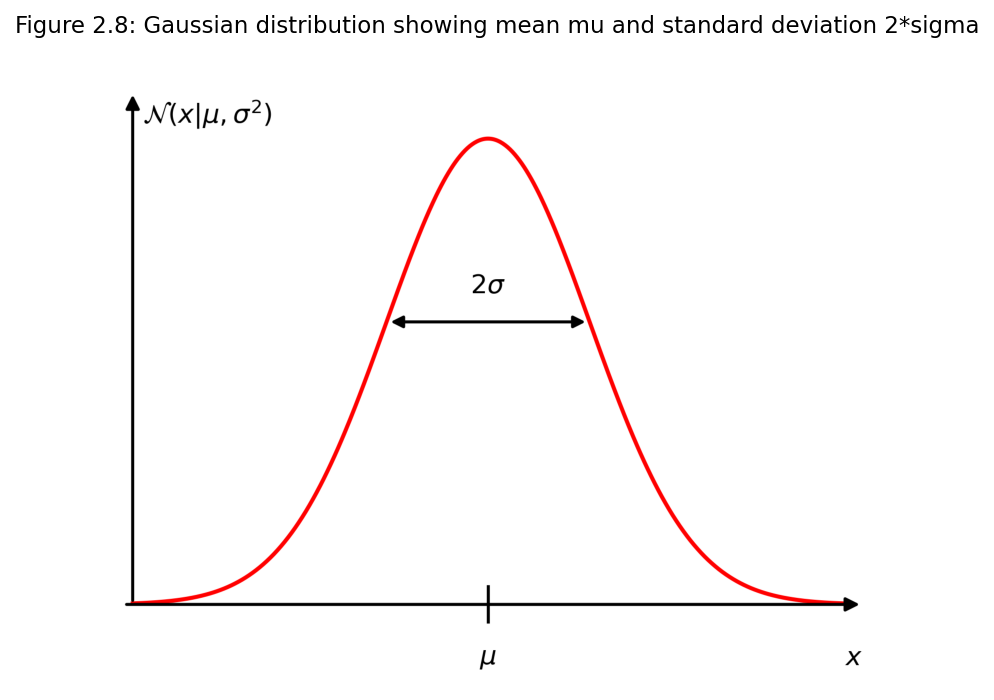

In [3]:
# Figure 2.8 の生成と表示
from scripts.generate_ch2_3_figures import generate_figure_2_8

generate_figure_2_8(save_dirs=["result", "2/result"])

img2_8 = plt.imread("2/result/fig2_08_gaussian_distribution.png")
fig, ax = plt.subplots(figsize=(6, 4.8), dpi=150)
ax.imshow(img2_8)
ax.axis("off")
ax.set_title("Figure 2.8: Gaussian distribution showing mean mu and standard deviation 2*sigma", fontsize=11, pad=10)
plt.tight_layout()
plt.show()


<a id="sec2_3_1"></a>
---
### 2.3.1 平均と分散 (Mean and Variance)

ガウス分布において、パラメータ $\mu$ は期待値（1次モーメント）、$\sigma^2$ は分散（2次中心モーメント）に完全に一致します。この重要な事実を数学的に厳密に導出します。

#### 1. 1次モーメント（平均）の導出 (式 2.52)
期待値の定義より：
$$
\mathbb{E}[x] = \int_{-\infty}^{\infty} \mathcal{N}(x | \mu, \sigma^2) \, x \, \mathrm{d}x \tag{2.52}
$$

**【導出ステップ】**:
$y = x - \mu$ と置換すると、$x = y + \mu$ かつ $\mathrm{d}x = \mathrm{d}y$ となります：
$$
\mathbb{E}[x] = \int_{-\infty}^{\infty} \frac{1}{(2\pi \sigma^2)^{1/2}} \exp \left( -\frac{y^2}{2\sigma^2} \right) (y + \mu) \, \mathrm{d}y
$$
これを2つの積分に分割します：
$$
\mathbb{E}[x] = \frac{1}{(2\pi \sigma^2)^{1/2}} \underbrace{\int_{-\infty}^{\infty} y \exp \left( -\frac{y^2}{2\sigma^2} \right) \mathrm{d}y}_{\text{(A) 奇関数の対称積分}} + \mu \underbrace{\int_{-\infty}^{\infty} \frac{1}{(2\pi \sigma^2)^{1/2}} \exp \left( -\frac{y^2}{2\sigma^2} \right) \mathrm{d}y}_{\text{(B) ガウス密度の全積分 = 1}}
$$
- 項 (A): 被積分関数 $f(y) = y \exp\left(-\frac{y^2}{2\sigma^2}\right)$ は奇関数（$f(-y) = -f(y)$）であり、対称区間 $(-\infty, \infty)$ での積分は厳密に $0$ です。
- 項 (B): これは平均 $0$, 分散 $\sigma^2$ のガウス密度の正規化積分そのものであるため、値は $1$ です。

したがって：
$$
\mathbb{E}[x] = 0 + \mu \cdot 1 = \mu
$$
となり、パラメータ $\mu$ が分布の平均値（期待値）であることが証明されました。

---

#### 2. 2次モーメントの導出 (式 2.53)
次に、$x^2$ の期待値を求めます：
$$
\mathbb{E}[x^2] = \int_{-\infty}^{\infty} \mathcal{N}(x | \mu, \sigma^2) \, x^2 \, \mathrm{d}x \tag{2.53}
$$

**【導出ステップ】**:
同様に $y = x - \mu$ （すなわち $x^2 = (y + \mu)^2 = y^2 + 2\mu y + \mu^2$）を代入して展開します：
$$
\mathbb{E}[x^2] = \int_{-\infty}^{\infty} \frac{1}{(2\pi \sigma^2)^{1/2}} \exp \left( -\frac{y^2}{2\sigma^2} \right) (y^2 + 2\mu y + \mu^2) \, \mathrm{d}y
$$
3つの項に分解すると：
1. **$2\mu y$ の項**: 奇関数の積分であるため $0$ となります。
2. **$\mu^2$ の項**: $\mu^2 \times 1 = \mu^2$ となります。
3. **$y^2$ の項**:
   $$
   K = \frac{1}{(2\pi \sigma^2)^{1/2}} \int_{-\infty}^{\infty} y^2 \exp \left( -\frac{y^2}{2\sigma^2} \right) \mathrm{d}y
   $$
   部分積分法（$\int u v' \mathrm{d}y = u v - \int u' v \mathrm{d}y$）を適用します：
   - $u = y \implies u' = 1$
   - $v' = y \exp\left(-\frac{y^2}{2\sigma^2}\right) \implies v = -\sigma^2 \exp\left(-\frac{y^2}{2\sigma^2}\right)$

   $$
   \begin{aligned}
   \int_{-\infty}^{\infty} y^2 \exp \left( -\frac{y^2}{2\sigma^2} \right) \mathrm{d}y &= \left[ -y \sigma^2 \exp\left(-\frac{y^2}{2\sigma^2}\right) \right]_{-\infty}^{\infty} - \int_{-\infty}^{\infty} 1 \cdot \left(-\sigma^2 \exp\left(-\frac{y^2}{2\sigma^2}\right)\right) \mathrm{d}y \\
   &= 0 + \sigma^2 \int_{-\infty}^{\infty} \exp\left(-\frac{y^2}{2\sigma^2}\right) \mathrm{d}y \\
   &= \sigma^2 \cdot (2\pi \sigma^2)^{1/2}
   \end{aligned}
   $$
   したがって、$K = \frac{1}{(2\pi \sigma^2)^{1/2}} \cdot \sigma^2 (2\pi \sigma^2)^{1/2} = \sigma^2$ となります。

以上を合わせると、式 (2.53) が導かれます：
$$
\mathbb{E}[x^2] = \mu^2 + \sigma^2 \tag{2.53}
$$

---

#### 3. 分散と最頻値 (式 2.54)
分散の定義式 $\text{var}[x] = \mathbb{E}[x^2] - (\mathbb{E}[x])^2$ に代入すると：
$$
\text{var}[x] = (\mu^2 + \sigma^2) - \mu^2 = \sigma^2 \tag{2.54}
$$
したがって、パラメータ $\sigma^2$ は分布の分散に一致します。

また、確率密度関数が最大値をとる値である **最頻値 (モード: Mode)** を求めるため、対数確率密度の1階微分をゼロとおくと：
$$
\frac{\mathrm{d}}{\mathrm{d}x} \ln \mathcal{N}(x | \mu, \sigma^2) = -\frac{x - \mu}{\sigma^2} = 0 \implies x_{\mathrm{mode}} = \mu
$$
ガウス分布は $\mu$ に関して完全に対称であるため、**平均 (Mean)、中央値 (Median)、最頻値 (Mode) がすべて一致する** という極めて端正な性質を持ちます。


In [4]:
# モーメントの数値積分と理論値の一致検証
mu_target = 3.5
sigma2_target = 2.25
sigma_target = np.sqrt(sigma2_target)
g_mom = Gaussian1D(mu=mu_target, sigma2=sigma2_target)

# 数値積分
e_x_num, _ = integrate.quad(lambda x: x * g_mom.pdf(x), -np.inf, np.inf)
e_x2_num, _ = integrate.quad(lambda x: (x**2) * g_mom.pdf(x), -np.inf, np.inf)
var_num = e_x2_num - (e_x_num ** 2)

print("=== ガウス分布のモーメント検証 (式 2.52 - 2.54) ===")
print(f"平均 E[x]:    理論値 = {mu_target:.6f}, 数値積分値 = {e_x_num:.6f}")
print(f"2次 E[x^2]:   理論値 = {mu_target**2 + sigma2_target:.6f}, 数値積分値 = {e_x2_num:.6f}")
print(f"分散 var[x]: 理論値 = {sigma2_target:.6f}, 数値積分値 = {var_num:.6f}")
print(f"最頻値 mode: 理論値 = {g_mom.mode:.6f}")


=== ガウス分布のモーメント検証 (式 2.52 - 2.54) ===
平均 E[x]:    理論値 = 3.500000, 数値積分値 = 3.500000
2次 E[x^2]:   理論値 = 14.500000, 数値積分値 = 14.500000
分散 var[x]: 理論値 = 2.250000, 数値積分値 = 2.250000
最頻値 mode: 理論値 = 3.500000


<a id="sec2_3_2"></a>
---
### 2.3.2 尤度関数 (Likelihood Function)

未知のガウス分布から得られた観測データ集合 $\mathbf{x} = (x_1, \dots, x_N)^T$ があるとき、モデルパラメータ $\mu$ および $\sigma^2$ をデータから決定する標準的アプローチが **最尤推定法 (Maximum Likelihood Estimation: MLE)** です。

観測値 $\{x_n\}$ が同一のガウス分布から互いに独立に生成された（**独立同分布: i.i.d. (independent and identically distributed)**）と仮定すると、データセット全体の結合確率は各データ点の確率密度の積として表されます。これをパラメータの関数とみなしたものを **尤度関数 (Likelihood Function)** と呼びます：

$$
p(\mathbf{x} | \mu, \sigma^2) = \prod_{n=1}^{N} \mathcal{N}(x_n | \mu, \sigma^2) \tag{2.55}
$$

### 教科書図版の再現: Figure 2.9
教科書 Figure 2.9 では、赤線で描かれたガウス曲線と、$x$ 軸上に散らばるデータ点 $\{x_n\}$（灰色）、およびそれらの点におけるガウス曲線の高さ $\mathcal{N}(x_n | \mu, \sigma^2)$（青点）が示されています。尤度関数とは、まさにこれらすべての青点の高さの「総乗」です。


Figure saved successfully to: result/fig2_09_gaussian_likelihood.png
Figure saved successfully to: 2/result/fig2_09_gaussian_likelihood.png


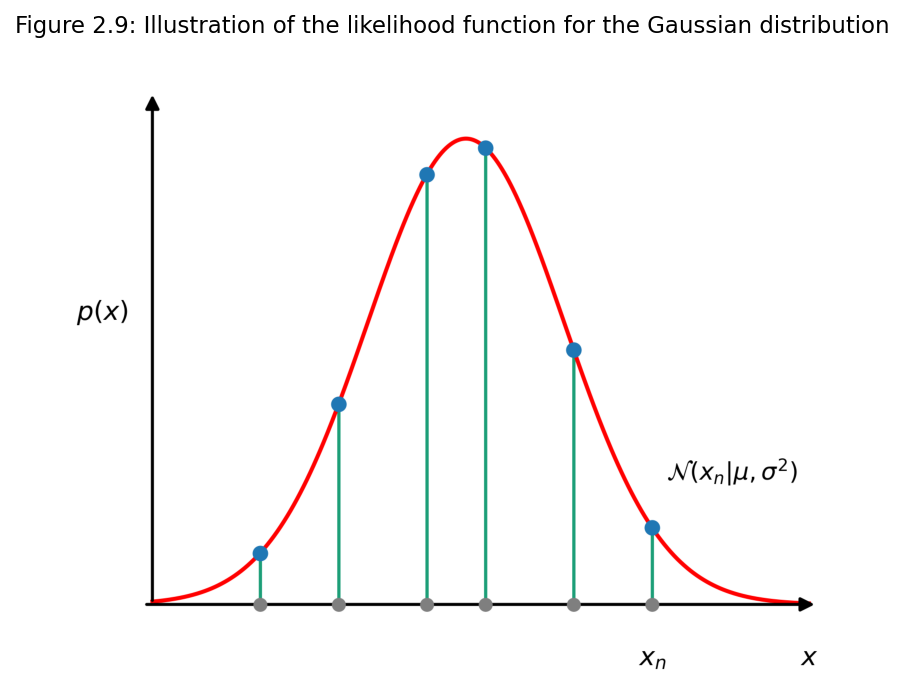

In [5]:
# Figure 2.9 の生成と表示
from scripts.generate_ch2_3_figures import generate_figure_2_9

generate_figure_2_9(save_dirs=["result", "2/result"])

img2_9 = plt.imread("2/result/fig2_09_gaussian_likelihood.png")
fig, ax = plt.subplots(figsize=(6, 4.8), dpi=150)
ax.imshow(img2_9)
ax.axis("off")
ax.set_title("Figure 2.9: Illustration of the likelihood function for the Gaussian distribution", fontsize=11, pad=10)
plt.tight_layout()
plt.show()


#### 対数尤度関数の厳密な導出 (式 2.56)
多数の確率値（$0$ から $1$ 未満の値）の総乗を直接計算すると、コンピュータ上では深刻な **アンダーフロー (Underflow)** を引き起こします。また、微分の計算も積の形より和の形の方が遥かに簡単です。
対数関数 $\ln(\cdot)$ は狭義単調増加関数であるため、**尤度関数を最大化することと対数尤度関数を最大化することは完全に等価** です。

式 (2.49) を式 (2.55) に代入して自然対数をとります：
$$
\begin{aligned}
\ln p(\mathbf{x} | \mu, \sigma^2) &= \ln \left[ \prod_{n=1}^{N} \frac{1}{(2\pi \sigma^2)^{1/2}} \exp \left( -\frac{1}{2\sigma^2}(x_n - \mu)^2 \right) \right] \\
&= \sum_{n=1}^{N} \ln \left[ (2\pi \sigma^2)^{-1/2} \exp \left( -\frac{1}{2\sigma^2}(x_n - \mu)^2 \right) \right] \\
&= \sum_{n=1}^{N} \left[ -\frac{1}{2} \ln(2\pi) - \frac{1}{2}\ln(\sigma^2) - \frac{1}{2\sigma^2}(x_n - \mu)^2 \right]
\end{aligned}
$$
各項を $N$ 個の和としてまとめると、式 (2.56) が得られます：

$$
\ln p(\mathbf{x} | \mu, \sigma^2) = -\frac{1}{2\sigma^2} \sum_{n=1}^{N}(x_n - \mu)^2 - \frac{N}{2}\ln \sigma^2 - \frac{N}{2}\ln(2\pi) \tag{2.56}
$$

---

#### 最尤解 $\mu_{\mathrm{ML}}$ の導出 (式 2.57)
対数尤度関数を $\mu$ について偏微分し、$0$ と置きます：
$$
\frac{\partial \ln p}{\partial \mu} = -\frac{1}{2\sigma^2} \sum_{n=1}^{N} 2(x_n - \mu)(-1) = \frac{1}{\sigma^2}\sum_{n=1}^{N}(x_n - \mu) = 0
$$
両辺に $\sigma^2 > 0$ を掛けると：
$$
\sum_{n=1}^{N} x_n - N\mu = 0 \implies \mu_{\mathrm{ML}} = \frac{1}{N}\sum_{n=1}^{N} x_n \tag{2.57}
$$
これは観測データの算術平均である **標本平均 (Sample Mean)** に他なりません。

---

#### 最尤解 $\sigma^2_{\mathrm{ML}}$ の導出 (式 2.58)
次に対数尤度関数を $\sigma^2$ について偏微分します（計算を明瞭にするため $s = \sigma^2$ と置きます）：
$$
\ln p = -\frac{1}{2s}\sum_{n=1}^{N}(x_n - \mu)^2 - \frac{N}{2}\ln s - \frac{N}{2}\ln(2\pi)
$$
$s$ で微分して $0$ と置きます：
$$
\frac{\partial \ln p}{\partial s} = \frac{1}{2s^2}\sum_{n=1}^{N}(x_n - \mu)^2 - \frac{N}{2s} = 0
$$
両辺に $2s^2$ を掛けると：
$$
\sum_{n=1}^{N}(x_n - \mu)^2 - N s = 0 \implies s = \frac{1}{N}\sum_{n=1}^{N}(x_n - \mu)^2
$$
ここに先ほど求めた最尤推定量 $\mu_{\mathrm{ML}}$ を代入することで、最尤分散 $\sigma^2_{\mathrm{ML}}$ が求まります：

$$
\sigma^2_{\mathrm{ML}} = \frac{1}{N}\sum_{n=1}^{N}(x_n - \mu_{\mathrm{ML}})^2 \tag{2.58}
$$
これは標本平均に対する分散である **標本分散 (Sample Variance)** です。

> [!NOTE]
> **パラメータ推定の分離性 (Decoupling)**:
> $\frac{\partial \ln p}{\partial \mu} = 0$ の解である $\mu_{\mathrm{ML}}$ には $\sigma^2$ が一切含まれていません。したがって、まず $\sigma^2$ に依存せずに $\mu$ を単独で解くことができ、その後で得られた $\mu_{\mathrm{ML}}$ を使って $\sigma^2$ を解くことができるという美しい分離特性（Decoupling）を持っています。


In [6]:
# 最尤推定の計算実験
sample_data = np.array([1.5, 2.1, 1.8, 3.2, 2.5, 2.9, 1.9, 2.7])
res_mle = gaussian_maximum_likelihood(sample_data)

print("=== ガウス分布の最尤推定結果 (式 2.57, 2.58) ===")
print(f"サンプル数 N:               {res_mle['N']}")
print(f"最尤平均 mu_ML:             {res_mle['mu_ML']:.4f}")
print(f"最尤分散 sigma^2_ML:        {res_mle['sigma2_ML']:.4f}")
print(f"最尤標準偏差 sigma_ML:      {res_mle['sigma_ML']:.4f}")
print(f"不偏分散 sigma^2_unbiased:  {res_mle['sigma2_unbiased']:.4f}")
print(f"最大対数尤度 log p(x|theta): {res_mle['log_likelihood']:.4f}")


=== ガウス分布の最尤推定結果 (式 2.57, 2.58) ===
サンプル数 N:               8
最尤平均 mu_ML:             2.3250
最尤分散 sigma^2_ML:        0.3069
最尤標準偏差 sigma_ML:      0.5540
不偏分散 sigma^2_unbiased:  0.3507
最大対数尤度 log p(x|theta): -6.6262


<a id="sec2_3_3"></a>
---
### 2.3.3 最尤推定のバイアス (Bias of Maximum Likelihood)

最尤推定法は広く用いられる強力な手法ですが、**有限の標本数 $N$ においてモデルの分散を系統的に過小評価する「バイアス (偏り)」を抱えている** という重大な制限があります。このバイアスは、機械学習における「過学習 (Overfitting)」の根本原理と直接結びついています。

#### 推定量のバイアスの定義
未知の真のパラメータ $\theta$ に対する推定量 $\hat{\theta}$ のバイアスは、推定量の期待値と真値との差として定義されます：
$$
\mathrm{Bias}(\hat{\theta}) = \mathbb{E}[\hat{\theta}] - \theta
$$
$\mathbb{E}[\hat{\theta}] = \theta$ が成り立つとき、推定量 $\hat{\theta}$ は **不偏 (Unbiased)** であると呼ばれます。

---

#### 1. 標本平均 $\mu_{\mathrm{ML}}$ の不偏性の証明 (式 2.59)
期待値演算子の線形性を用いると：
$$
\mathbb{E}[\mu_{\mathrm{ML}}] = \mathbb{E}\left[ \frac{1}{N}\sum_{n=1}^{N} x_n \right] = \frac{1}{N}\sum_{n=1}^{N} \mathbb{E}[x_n] = \frac{1}{N} \cdot N \mu = \mu \tag{2.59}
$$
したがって、**最尤平均推定量 $\mu_{\mathrm{ML}}$ は厳密に不偏推定量** です。

---

#### 2. 標本分散 $\sigma^2_{\mathrm{ML}}$ のバイアスの完全証明 (式 2.60)
最尤分散推定量 $\sigma^2_{\mathrm{ML}}$ の期待値を計算します：
$$
\mathbb{E}[\sigma^2_{\mathrm{ML}}] = \mathbb{E}\left[ \frac{1}{N}\sum_{n=1}^{N} (x_n - \mu_{\mathrm{ML}})^2 \right]
$$

**【導出ステップ】**:
1. 偏差項に真の平均 $\mu$ を足し引きして分解します：
   $$
   x_n - \mu_{\mathrm{ML}} = (x_n - \mu) - (\mu_{\mathrm{ML}} - \mu)
   $$
2. 2乗して $n=1$ から $N$ まで総和をとります：
   $$
   \begin{aligned}
   \sum_{n=1}^{N} (x_n - \mu_{\mathrm{ML}})^2 &= \sum_{n=1}^{N} \left[ (x_n - \mu) - (\mu_{\mathrm{ML}} - \mu) \right]^2 \\
   &= \sum_{n=1}^{N} (x_n - \mu)^2 - 2(\mu_{\mathrm{ML}} - \mu)\underbrace{\sum_{n=1}^{N}(x_n - \mu)}_{= N(\mu_{\mathrm{ML}} - \mu)} + \sum_{n=1}^{N}(\mu_{\mathrm{ML}} - \mu)^2 \\
   &= \sum_{n=1}^{N} (x_n - \mu)^2 - 2N(\mu_{\mathrm{ML}} - \mu)^2 + N(\mu_{\mathrm{ML}} - \mu)^2 \\
   &= \sum_{n=1}^{N} (x_n - \mu)^2 - N(\mu_{\mathrm{ML}} - \mu)^2
   \end{aligned}
   $$

3. 両辺の期待値をとります：
   - 第1項: $\mathbb{E}\left[\sum_{n=1}^{N} (x_n - \mu)^2\right] = \sum_{n=1}^{N} \mathbb{E}[(x_n - \mu)^2] = N \sigma^2$
   - 第2項: $\mathbb{E}\left[(\mu_{\mathrm{ML}} - \mu)^2\right]$ は標本平均の分散そのものです：
     $$
     \text{var}[\mu_{\mathrm{ML}}] = \text{var}\left[ \frac{1}{N}\sum_{n=1}^{N} x_n \right] = \frac{1}{N^2}\sum_{n=1}^{N}\text{var}[x_n] = \frac{1}{N^2} \cdot N \sigma^2 = \frac{\sigma^2}{N}
     $$
     したがって、$N \mathbb{E}[(\mu_{\mathrm{ML}} - \mu)^2] = N \cdot \frac{\sigma^2}{N} = \sigma^2$ となります。

4. 差し引きを計算します：
   $$
   \mathbb{E}\left[ \sum_{n=1}^{N} (x_n - \mu_{\mathrm{ML}})^2 \right] = N\sigma^2 - \sigma^2 = (N - 1)\sigma^2
   $$
   両辺を $N$ で割ると、式 (2.60) が導かれます：

$$
\mathbb{E}[\sigma^2_{\mathrm{ML}}] = \left( \frac{N - 1}{N} \right) \sigma^2 \tag{2.60}
$$

これにより、**最尤分散推定量は真の分散を係数 $\frac{N-1}{N}$ だけ系統的に過小評価する** ことが数学的に証明されました。

---

#### 3. 真の平均を知っている場合の推定量との比較 (式 2.61, 2.62)
もし仮に真の平均 $\mu$ が既知である場合、分散推定量として以下を定義できます：
$$
\hat{\sigma}^2 \equiv \frac{1}{N}\sum_{n=1}^{N} (x_n - \mu)^2 \tag{2.61}
$$
この推定量の期待値をとると：
$$
\mathbb{E}[\hat{\sigma}^2] = \frac{1}{N}\sum_{n=1}^{N} \mathbb{E}[(x_n - \mu)^2] = \frac{1}{N} \cdot N \sigma^2 = \sigma^2 \tag{2.62}
$$
となり、完全に不偏です。
すなわち、**分散が過小評価される原因は、「真の平均 $\mu$」の代わりに「同一データから計算した標本平均 $\mu_{\mathrm{ML}}$」を基準に偏差を測っているため、データが平均の周りに必然的によりコンパクトに集まってしまうから** です（自由度が1つ消費される）。

---

#### 4. ベッセル補正による不偏分散推定量 (式 2.63)
式 (2.60) より、最尤分散に補正係数 $\frac{N}{N-1}$ を乗じることで、不偏な推定量 $\tilde{\sigma}^2$ を構築できます：

$$
\tilde{\sigma}^2 = \frac{N}{N - 1} \sigma^2_{\mathrm{ML}} = \frac{1}{N - 1} \sum_{n=1}^{N} (x_n - \mu_{\mathrm{ML}})^2 \tag{2.63}
$$
この分母の $N-1$ は **ベッセル補正 (Bessel's Correction)** と呼ばれ、$\mathbb{E}[\tilde{\sigma}^2] = \sigma^2$ が厳密に保証されます。


### 教科書図版の再現: Figure 2.10
教科書 Figure 2.10 では、$N=2$ 個のデータ点（緑色）から得られる3つの異なるデータセットについて、真の分布（赤線）と最尤推定されたガウス分布（青線）を比較しています。
$N=2$ の場合、最尤分散の期待値は $\frac{2-1}{2}\sigma^2 = 0.5\sigma^2$ となり、真の分散の半分にまで激しく過小評価されます。そのため、青い曲線は赤い曲線に比べて著しく細く鋭い釣鐘型になります。


Figure saved successfully to: result/fig2_10_mle_bias.png
Figure saved successfully to: 2/result/fig2_10_mle_bias.png


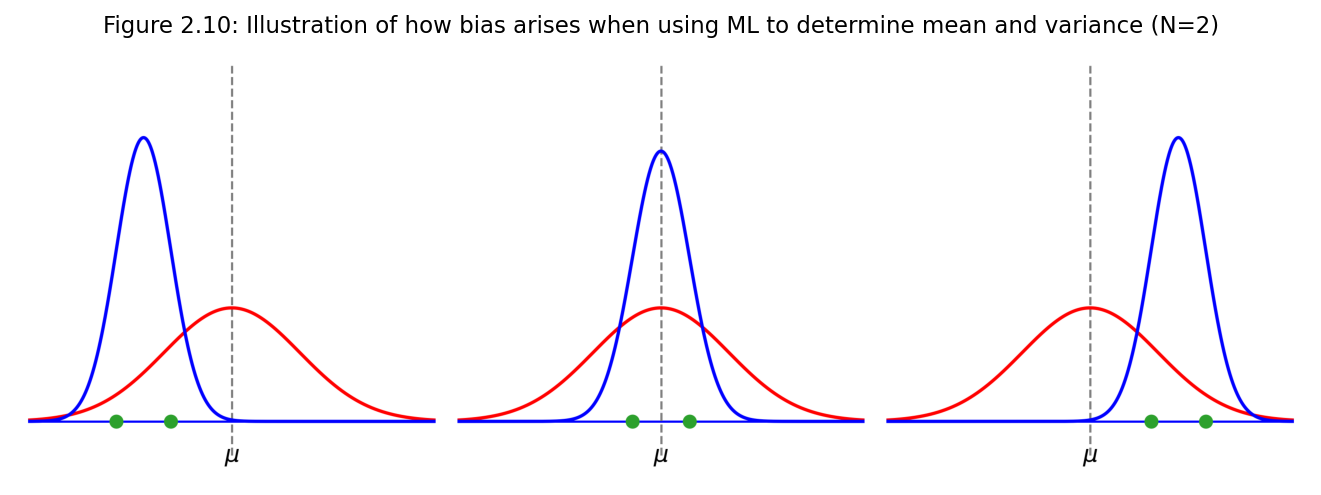

In [7]:
# Figure 2.10 の生成と表示
from scripts.generate_ch2_3_figures import generate_figure_2_10

generate_figure_2_10(save_dirs=["result", "2/result"])

img2_10 = plt.imread("2/result/fig2_10_mle_bias.png")
fig, ax = plt.subplots(figsize=(10, 3.4), dpi=150)
ax.imshow(img2_10)
ax.axis("off")
ax.set_title("Figure 2.10: Illustration of how bias arises when using ML to determine mean and variance (N=2)", fontsize=11, pad=10)
plt.tight_layout()
plt.show()


#### モンテカルロシミュレーションによるバイアスの実証
標本サイズ $N \in [2, 3, 5, 10, 20, 50, 100]$ について、それぞれ $100,000$ 回の試行を行い、標本分散 $\sigma^2_{\mathrm{ML}}$ と不偏分散 $\tilde{\sigma}^2$ の期待値をシミュレーションで測定します。


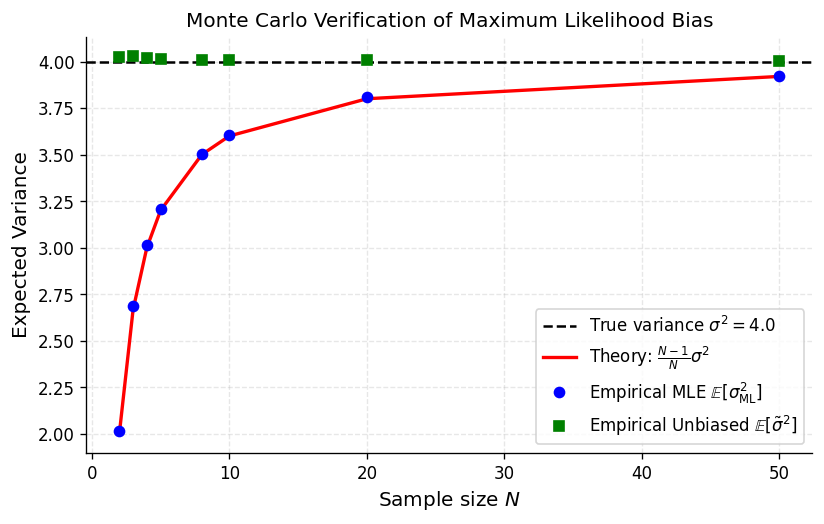

N = 2:  MLE分散期待値 = 2.0131 (理論値 = 2.0000) | 不偏分散期待値 = 4.0261
N = 10: MLE分散期待値 = 3.6051 (理論値 = 3.6000) | 不偏分散期待値 = 4.0057
N = 50: MLE分散期待値 = 3.9201 (理論値 = 3.9200) | 不偏分散期待値 = 4.0001


In [8]:
# モンテカルロ検証
N_values = [2, 3, 4, 5, 8, 10, 20, 50]
true_s2 = 4.0
true_mu = 1.0
n_sim = 50000

e_mle_list = []
e_unbiased_list = []
theory_list = []

for N in N_values:
    res = simulate_gaussian_mle_bias(mu=true_mu, sigma2=true_s2, N=N, n_trials=n_sim, seed=42)
    e_mle_list.append(res["E_sigma2_ML"])
    e_unbiased_list.append(res["E_sigma2_tilde"])
    theory_list.append(res["theoretical_E_sigma2_ML"])

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=120)
ax.axhline(true_s2, color='black', linestyle='--', linewidth=1.5, label=r'True variance $\sigma^2 = 4.0$')
ax.plot(N_values, theory_list, 'r-', linewidth=2.0, label=r'Theory: $\frac{N-1}{N}\sigma^2$')
ax.plot(N_values, e_mle_list, 'bo', markersize=6, label=r'Empirical MLE $\mathbb{E}[\sigma^2_{\mathrm{ML}}]$')
ax.plot(N_values, e_unbiased_list, 'gs', markersize=6, label=r'Empirical Unbiased $\mathbb{E}[\tilde{\sigma}^2]$')

ax.set_xlabel("Sample size $N$", fontsize=12)
ax.set_ylabel("Expected Variance", fontsize=12)
ax.set_title("Monte Carlo Verification of Maximum Likelihood Bias", fontsize=12)
ax.legend(loc='lower right', frameon=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"N = 2:  MLE分散期待値 = {e_mle_list[0]:.4f} (理論値 = {theory_list[0]:.4f}) | 不偏分散期待値 = {e_unbiased_list[0]:.4f}")
print(f"N = 10: MLE分散期待値 = {e_mle_list[5]:.4f} (理論値 = {theory_list[5]:.4f}) | 不偏分散期待値 = {e_unbiased_list[5]:.4f}")
print(f"N = 50: MLE分散期待値 = {e_mle_list[7]:.4f} (理論値 = {theory_list[7]:.4f}) | 不偏分散期待値 = {e_unbiased_list[7]:.4f}")


<a id="sec2_3_4"></a>
---
### 2.3.4 線形回帰 (Linear Regression)

第1章 1.1節で導入した「多項式フィッティング」は、ヒューリスティックに最小二乗法を適用したものでした。
本節では、ガウス分布を用いて線形回帰を **確率的モデル (Probabilistic Model)** として再定式化し、**二乗和誤差関数の最小化がガウスノイズ仮定下での最尤推定と厳密に一致する** ことを明らかにします。

#### 目的変数の条件付きガウス分布 (式 2.64)
入力変数 $x$ が与えられたときの連続な目標変数 $t$ の不確実性をモデル化するため、$t$ の条件付き確率分布が多項式関数 $y(x, \mathbf{w})$ を平均とし、未知の精度 $\beta = 1/\sigma^2$（分散 $\sigma^2$）を持つガウス分布に従うと仮定します：

$$
p(t | x, \mathbf{w}, \sigma^2) = \mathcal{N}(t | y(x; \mathbf{w}), \sigma^2) \tag{2.64}
$$

ここで $y(x; \mathbf{w}) = \sum_{j=0}^{M} w_j x^j = \mathbf{w}^T \boldsymbol{\phi}(x)$ は入力 $x$ に対する予測平均値です。

### 教科書図版の再現: Figure 2.11
教科書 Figure 2.11 では、青いデータ点が散らばる中に引かれた赤い回帰曲線 $y(x, \mathbf{w})$、および特定の位置 $x_0$ における垂直断面上に現れる釣鐘型の条件付きガウス分布 $p(t | x_0, \mathbf{w}, \sigma^2)$ が示されています。
回帰曲線は「各入力 $x$ における $t$ の平均値」の軌跡であり、その周りのばらつき幅が $\sigma$ で決まります。


Figure saved successfully to: result/fig2_11_linear_regression_conditional_gaussian.png
Figure saved successfully to: 2/result/fig2_11_linear_regression_conditional_gaussian.png


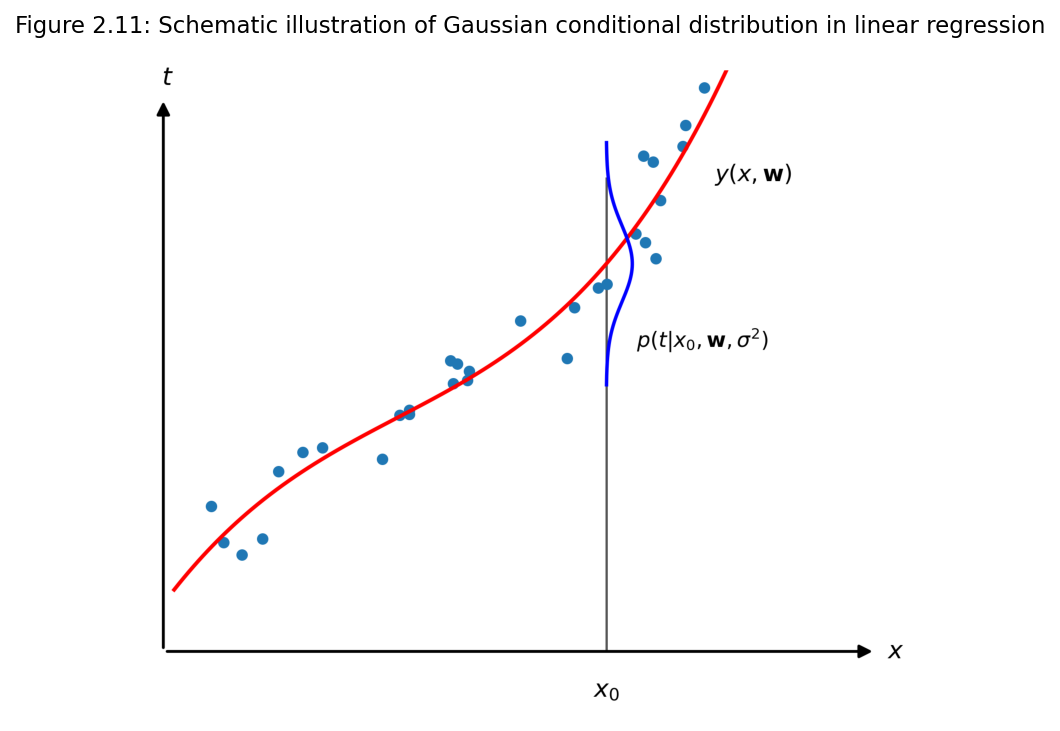

In [9]:
# Figure 2.11 の生成と表示
from scripts.generate_ch2_3_figures import generate_figure_2_11

generate_figure_2_11(save_dirs=["result", "2/result"])

img2_11 = plt.imread("2/result/fig2_11_linear_regression_conditional_gaussian.png")
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
ax.imshow(img2_11)
ax.axis("off")
ax.set_title("Figure 2.11: Schematic illustration of Gaussian conditional distribution in linear regression", fontsize=11, pad=10)
plt.tight_layout()
plt.show()


#### 尤度関数と二乗和誤差の等価性 (式 2.65 - 2.67)
独立同分布の訓練データ $\{\mathbf{x}, \mathbf{t}\} = \{(x_n, t_n)\}_{n=1}^N$ に対し、目標変数ベクトル $\mathbf{t} = (t_1, \dots, t_N)^T$ の尤度関数は以下のようになります：

$$
p(\mathbf{t} | \mathbf{x}, \mathbf{w}, \sigma^2) = \prod_{n=1}^{N} \mathcal{N}(t_n | y(x_n; \mathbf{w}), \sigma^2) \tag{2.65}
$$

両辺の自然対数をとると、対数尤度関数が得られます：

$$
\ln p(\mathbf{t} | \mathbf{x}, \mathbf{w}, \sigma^2) = -\frac{1}{2\sigma^2}\sum_{n=1}^{N} \{ y(x_n; \mathbf{w}) - t_n \}^2 - \frac{N}{2}\ln \sigma^2 - \frac{N}{2}\ln(2\pi) \tag{2.66}
$$

この式から、極めて本質的な事実が導かれます：
重みパラメータ $\mathbf{w}$ を決定する際、第2項と第3項は $\mathbf{w}$ に依存しません。また、第1項の係数 $\frac{1}{2\sigma^2}$ は正の定数です。
したがって、**対数尤度 $\ln p$ を最大化することは、以下の二乗和誤差関数 $E(\mathbf{w})$ を最小化することと完全に同値** です：

$$
E(\mathbf{w}) = \frac{1}{2}\sum_{n=1}^{N} \{ y(x_n; \mathbf{w}) - t_n \}^2 \tag{2.67}
$$

すなわち、第1章で直感的に導入した「二乗和誤差の最小化」は、**「誤差が独立なガウスノイズに従うという確率モデルのもとでの最尤推定」として数学的に厳密に正当化** されます。

---

#### ノイズ分散の最尤推定量 (式 2.68)
対数尤度関数 (2.66) を $\sigma^2$ について偏微分して $0$ と置くことで、ノイズ分散の最尤推定量 $\sigma^2_{\mathrm{ML}}$ が得られます：

$$
\sigma^2_{\mathrm{ML}} = \frac{1}{N}\sum_{n=1}^{N} \{ y(x_n; \mathbf{w}_{\mathrm{ML}}) - t_n \}^2 \tag{2.68}
$$
これは、最尤最適化された回帰モデルの残差平方和の平均値です。

---

#### 予測分布 (式 2.69)
パラメータの最尤推定量 $\mathbf{w}_{\mathrm{ML}}$ および $\sigma^2_{\mathrm{ML}}$ が求まると、任意の新たな入力 $x$ に対する予測値は単一の点予測ではなく、**予測分布 (Predictive Distribution)** という確率分布全体として表現されます：

$$
p(t | x, \mathbf{w}_{\mathrm{ML}}, \sigma^2_{\mathrm{ML}}) = \mathcal{N}(t | y(x; \mathbf{w}_{\mathrm{ML}}), \sigma^2_{\mathrm{ML}}) \tag{2.69}
$$
この予測分布により、平均値 $y(x; \mathbf{w}_{\mathrm{ML}})$ の予測だけでなく、モデルが予測に伴う不確実性の幅（例えば $\pm 1\sigma_{\mathrm{ML}}$ や $\pm 2\sigma_{\mathrm{ML}}$ の信頼区間）を定量的に提供できるようになります。


真のノイズ標準偏差:     sigma = 0.2000
最尤推定ノイズ標準偏差: sigma_ML = 0.1878


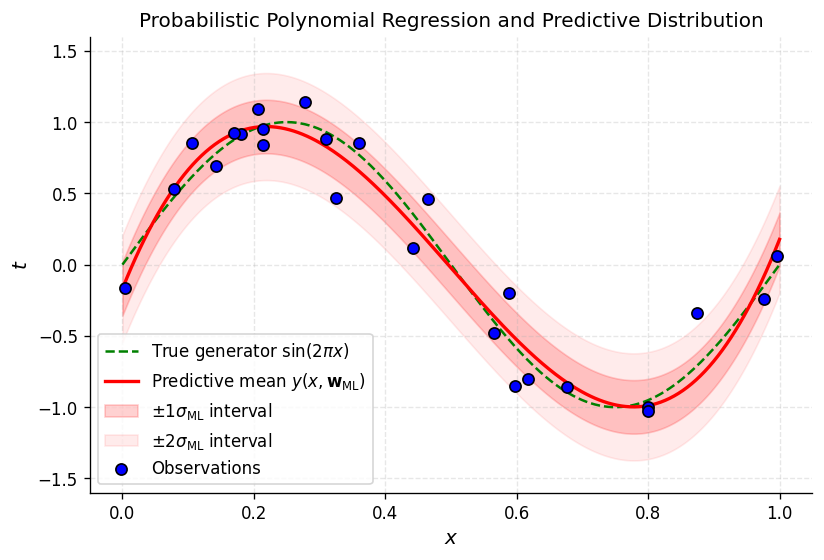

In [10]:
# 確率的線形回帰の実装と予測分布の可視化
rng = np.random.default_rng(2024)

# 合成データの作成
N_pts = 25
x_obs = rng.uniform(0.0, 1.0, N_pts)
true_func = lambda x: np.sin(2 * np.pi * x)
true_sigma = 0.2
t_obs = true_func(x_obs) + rng.normal(0, true_sigma, N_pts)

# 3次多項式モデルで適合
deg = 3
reg_model = GaussianLinearRegression(degree=deg)
reg_model.fit(x_obs, t_obs)

print(f"真のノイズ標準偏差:     sigma = {true_sigma:.4f}")
print(f"最尤推定ノイズ標準偏差: sigma_ML = {reg_model.sigma_ml:.4f}")

# 予測分布の描画
x_grid = np.linspace(0.0, 1.0, 300)
y_mean, sigma_pred = reg_model.predict(x_grid)

fig, ax = plt.subplots(figsize=(7, 4.8), dpi=120)
# 真の関数
ax.plot(x_grid, true_func(x_grid), 'g--', linewidth=1.5, label='True generator $\sin(2\pi x)$')
# 予測平均
ax.plot(x_grid, y_mean, 'r-', linewidth=2.0, label=r'Predictive mean $y(x, \mathbf{w}_{\mathrm{ML}})$')
# 信頼区間帯 (Predictive distribution confidence bands: +- 1 sigma, +- 2 sigma)
ax.fill_between(x_grid, y_mean - sigma_pred, y_mean + sigma_pred, color='red', alpha=0.18, label=r'$\pm 1\sigma_{\mathrm{ML}}$ interval')
ax.fill_between(x_grid, y_mean - 2 * sigma_pred, y_mean + 2 * sigma_pred, color='red', alpha=0.08, label=r'$\pm 2\sigma_{\mathrm{ML}}$ interval')
# 観測データ点
ax.scatter(x_obs, t_obs, color='blue', edgecolors='k', s=45, zorder=5, label='Observations')

ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$t$', fontsize=12)
ax.set_title('Probabilistic Polynomial Regression and Predictive Distribution', fontsize=12)
ax.legend(loc='lower left', frameon=True)
ax.set_ylim(-1.6, 1.6)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<a id="sec2_3_dl"></a>
---
## 6. 深層学習との架け橋 (Deep Learning Connections)

本節で学んだガウス分布と最尤推定の理論は、現代の深層学習アーキテクチャや学習損失関数の設計基盤となっています。

### 1. 平均二乗誤差 (MSE Loss) の理論的正当化
深層ニューラルネットワーク（DNN）による回帰問題では、一般に出力層の損失関数として **平均二乗誤差 (Mean Squared Error: MSE)** が使用されます：
$$
\mathcal{L}_{\mathrm{MSE}}(\boldsymbol{\theta}) = \frac{1}{N}\sum_{n=1}^{N} \| f_{\boldsymbol{\theta}}(\mathbf{x}_n) - \mathbf{y}_n \|^2
$$
これはヒューリスティックに選ばれた関数ではなく、本節の式 (2.66), (2.67) で証明した通り、**「ターゲット $\mathbf{y}$ に等分散の等方ガウスノイズが加わっている」という確率的仮定のもとでの負の対数尤度最小化と完全に等価** です。

### 2. 変分オートエンコーダ (VAE) とガウス潜在変数
現代の生成モデルである **VAE (Variational Autoencoder)** では、潜在空間の事前分布 $p(\mathbf{z})$ として標準ガウス分布 $\mathcal{N}(\mathbf{0}, \mathbf{I})$ を採用し、エンコーダネットワークは潜在変数の平均 $\boldsymbol{\mu}_{\boldsymbol{\phi}}(\mathbf{x})$ と対数分散 $\ln \boldsymbol{\sigma}^2_{\boldsymbol{\phi}}(\mathbf{x})$ を出力します。
さらに、再パラメータ化トリック (Reparameterization Trick)：
$$
\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})
$$
によって、ガウス分布の確率的サンプリングを介した誤差逆伝播法（Backpropagation）を実現しています。

### 3. 拡散モデル (Diffusion Models)
近年の画像・動画生成AI（Stable Diffusion, Sora等）の中核技術である **拡散モデル (Denoising Diffusion Probabilistic Models: DDPM)** は、前方過程においてデータに微小なガウスノイズを段階的に付加し、逆過程においてニューラルネットワークがその各ステップのガウスノイズを予測・除去することで高品質なデータ生成を行います。

### 4. 過学習と最尤推定の限界
本節 2.3.3 で明らかにしたように、最尤推定は有限標本において分散を過小評価します（式 2.60）。深層学習において数百万〜数千億のパラメータを持つモデルを単純な最尤推定（損失最小化）だけで最適化すると、訓練データに対して激しい過学習を起こすのはこの原理に起因しています。
この問題を根本的に解決するのが、後の節で詳述される **正則化 (Weight Decay)**、および事前分布を導入して事後分布を求める **ベイズ的アプローチ (Bayesian Treatment)** です。

---

### まとめ (Summary)
| 概念 | 数式番号 | 主要な意味 |
| :--- | :--- | :--- |
| **1変量ガウス分布** | (2.49), (2.50) | 平均 $\mu$、分散 $\sigma^2$、精度 $\beta = 1/\sigma^2$ で規定される釣鐘型連続分布 |
| **正規化条件** | (2.51) | $\int \mathcal{N} \mathrm{d}x = 1$（ガウス積分と極座標変換による証明） |
| **平均・分散・最頻値** | (2.52) - (2.54) | $\mathbb{E}[x] = \mu$, $\mathbb{E}[x^2] = \mu^2 + \sigma^2$, $\text{var}[x] = \sigma^2$, $\text{mode} = \mu$ |
| **最尤推定量** | (2.57), (2.58) | $\mu_{\mathrm{ML}} = \frac{1}{N}\sum x_n$, $\sigma^2_{\mathrm{ML}} = \frac{1}{N}\sum (x_n - \mu_{\mathrm{ML}})^2$ |
| **最尤推定のバイアス** | (2.59), (2.60) | $\mathbb{E}[\mu_{\mathrm{ML}}] = \mu$（不偏）, $\mathbb{E}[\sigma^2_{\mathrm{ML}}] = \frac{N-1}{N}\sigma^2$（過小評価） |
| **不偏分散 (ベッセル補正)** | (2.63) | $\tilde{\sigma}^2 = \frac{N}{N-1}\sigma^2_{\mathrm{ML}} = \frac{1}{N-1}\sum (x_n - \mu_{\mathrm{ML}})^2$ |
| **確率的線形回帰** | (2.64) - (2.67) | 条件付きガウス分布 $p(t\|x) = \mathcal{N}(t\|y(x), \sigma^2)$、最尤推定は二乗和誤差最小化と厳密に等価 |
| **予測分布** | (2.68), (2.69) | $\mathcal{N}(t \| y(x; \mathbf{w}_{\mathrm{ML}}), \sigma^2_{\mathrm{ML}})$（予測値の期待値と不確実性の定量化） |
